In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support,accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
import joblib, os


In [2]:
os.makedirs('D:/cse/SEM5/INT234/Project/models', exist_ok=True)
os.makedirs('D:/cse/SEM5/INT234/Project/results', exist_ok=True)

In [3]:
df = pd.read_csv(r"D:\cse\SEM5\INT234\Project\model_ready.csv")
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [5]:
# No SMOTE, class_weight
rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       random_state=42)

In [6]:
prods = rf.predict(X_val)


In [7]:
auc = roc_auc_score(y_val, prods)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, prods, average='binary')
metrics = {'model':'Random_Forest(classWeight)','auc':auc,'precision':prec,'recall':rec,'f1':f1}




Model: Random_Forest
Accuracy: 0.8433333333333334
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      5041
           1       0.51      0.78      0.61       959

    accuracy                           0.84      6000
   macro avg       0.73      0.82      0.76      6000
weighted avg       0.88      0.84      0.86      6000



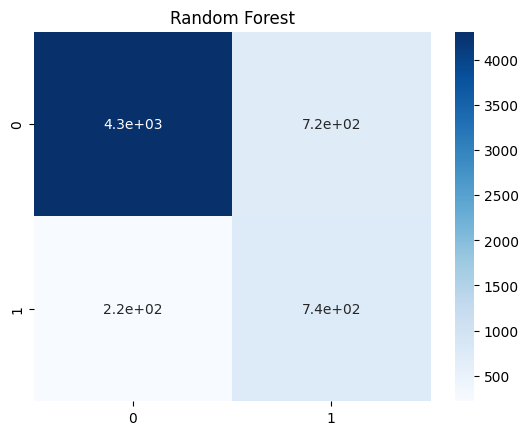

In [8]:
print(f"\nModel: Random_Forest")
print("Accuracy:", accuracy_score(y_val,prods))
print(classification_report(y_val, prods))
sns.heatmap(confusion_matrix(y_val,prods), annot=True, cmap="Blues")
plt.title("Random Forest")
plt.show()

In [9]:
joblib.dump(rf, "D:\cse\SEM5\INT234\Project\logreg_no_smote.pkl")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11772\2970344324.py:1: SyntaxWarning: invalid escape sequence '\c'
  joblib.dump(rf, "D:\cse\SEM5\INT234\Project\logreg_no_smote.pkl")


['D:\\cse\\SEM5\\INT234\\Project\\logreg_no_smote.pkl']

In [10]:
pd.DataFrame([metrics]).to_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv', mode='a', header=not os.path.exists('D:/cse/SEM5/INT234/Project/results/model_metrics.csv'), index=False)

In [11]:
# With SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [12]:
rf_sm = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight=None, random_state=42)
rf_sm.fit(X_res, y_res)

RandomForestClassifier(max_depth=12, n_estimators=300, random_state=42)

In [13]:
probs_sm = rf_sm.predict(X_val)


In [14]:
auc_sm = roc_auc_score(y_val, probs_sm)
prec_sm, rec_sm, f1_sm, _ = precision_recall_fscore_support(y_val, probs_sm, average='binary')

metrics_sm = {'model':'Random_Forest(Smote)','auc':auc,'precision':prec,'recall':rec,'f1':f1}




Model: Random_Forest(Smote)
Accuracy: 0.8468333333333333
              precision    recall  f1-score   support

           0       0.95      0.87      0.90      5041
           1       0.51      0.74      0.61       959

    accuracy                           0.85      6000
   macro avg       0.73      0.80      0.76      6000
weighted avg       0.88      0.85      0.86      6000



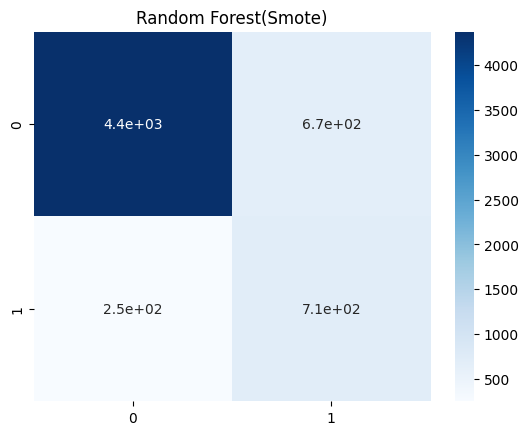

In [15]:
print(f"\nModel: Random_Forest(Smote)")
print("Accuracy:", accuracy_score(y_val,probs_sm))
print(classification_report(y_val, probs_sm))
sns.heatmap(confusion_matrix(y_val,probs_sm), annot=True, cmap="Blues")
plt.title("Random Forest(Smote)")
plt.show()

In [16]:
joblib.dump(rf_sm, 'D:/cse/SEM5/INT234/Project/models/rf_smote.pkl')

['D:/cse/SEM5/INT234/Project/models/rf_smote.pkl']

In [17]:
pd.DataFrame([metrics_sm]).to_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv', mode='a', header=False, index=False)